# DJA vs COSMOS2025 Dataset Comparison

Compares two aligned (image, spectrum) datasets:
- **DJA** — `DJA/dja_spectra_low_image.h5` — 11924 objects, has encoder embeddings
- **COSMOS** — `cosmosf150w_dja_low/dja_cosmos_matched.h5` — 1772 objects, no embeddings yet

Sections:
1. Dataset overview
2. Image examples
3. Spectrum examples
4. Statistics (sn50, z, n_valid, flux)
5. Encoder embedding space (DJA only — PCA + UMAP)

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('/home/yacheng/ssl_outthere/images')
JDA_H5    = ROOT / 'JDA/jda_spectra_low_image.h5'
COSMOS_H5 = ROOT / 'cosmosf150w_jda_low/jda_cosmos_matched.h5'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Unit correction ────────────────────────────────────────────────────────────
# JDA images were built by build_jda_image_spectrum_h5.py which assumed grizli
# mosaics were in nJy/pixel and multiplied by NJY_TO_MJY_SR = 1e-15/pix_sr.
# The grizli mosaics are actually already in MJy/sr (same as COSMOS-Web), so
# the stored JDA pixels are a factor of ~9.4× too faint.
# Cross-check: integrating the corrected images over 128×128 @ 30mas recovers
# phot_f150w_tot_1 to within ±25% (scatter from aperture vs total-flux definitions).
#
# NOTE: AstroDINO was trained on the stored (wrong-scale) JDA images, so the
# stored image_embed vectors correspond to those values. When running the encoder
# on new data (e.g., COSMOS), input images must be scaled DOWN by NJY_TO_MJY_SR
# to match the training distribution, OR the encoder must be re-trained.
_pix_sr_20mas    = (20e-3)**2 * (np.pi / (180.0 * 3600.0))**2   # sr per 20mas pixel
NJY_TO_MJY_SR    = 1e-15 / _pix_sr_20mas                         # = 0.10636
JDA_IMG_UNIT_FIX = 1.0 / NJY_TO_MJY_SR                          # = 9.40  (divide stored → true MJy/sr)

print(f'NJY_TO_MJY_SR   = {NJY_TO_MJY_SR:.5f}')
print(f'JDA_IMG_UNIT_FIX = {JDA_IMG_UNIT_FIX:.2f}  (multiply stored JDA image by this → true MJy/sr)')
print(f'COSMOS images: no correction needed (raw MJy/sr from JWST pipeline)')

## 1. Dataset overview

In [ ]:
def load_jda(h5):
    d = {}
    for k in ['flux','wave','sn50','z_best','grade','n_valid','image_embed','spectrum_embed']:
        if k in h5:
            d[k] = h5[k][:]
    # Apply unit correction: stored JDA images are ~9.4× too faint (wrong unit assumption)
    d['image'] = h5['image'][:] * JDA_IMG_UNIT_FIX  # now true MJy/sr
    return d

def load_cosmos(h5):
    d = {}
    d['image']  = h5['image/image'][:]   # MJy/sr directly (JWST pipeline)
    d['flux']   = h5['jda/flux'][:]
    d['wave']   = h5['jda/wave'][:]
    d['sn50']   = h5['jda/sn50'][:]
    d['z_best'] = h5['jda/z_best'][:]
    d['grade']  = h5['jda/grade'][:]
    d['sep_arcsec'] = h5['sep_arcsec'][:]
    flux, wave = d['flux'], d['wave']
    valid = (flux != 0.0) & np.isfinite(flux) & np.isfinite(wave)
    d['n_valid'] = valid.sum(axis=1).astype(np.int32)
    for k in ['axis_ratio','radius_sersic','sersic','snr_f150w','mass_minchi2','sfr_minchi2']:
        key = f'image/{k}'
        if key in h5:
            d[k] = h5[key][:]
    return d

with h5py.File(JDA_H5, 'r') as f:
    jda = load_jda(f)
with h5py.File(COSMOS_H5, 'r') as f:
    cos = load_cosmos(f)

print(f"JDA     N={len(jda['image']):6d}  image={jda['image'].shape}  flux={jda['flux'].shape}")
print(f"        image_embed={jda['image_embed'].shape}  spectrum_embed={jda['spectrum_embed'].shape}")
print(f"COSMOS  N={len(cos['image']):6d}  image={cos['image'].shape}  flux={cos['flux'].shape}")
print()
print('Image brightness after correction (both should be in MJy/sr):')
pix_sr_30 = (30e-3)**2 * (np.pi/(180*3600))**2
for label, imgs in [('JDA   ', jda['image']), ('COSMOS', cos['image'])]:
    p50, p99 = np.percentile(imgs, [50, 99])
    print(f'  {label}  p50={p50:.5f}  p99={p99:.4f} MJy/sr')

## 2. Image examples

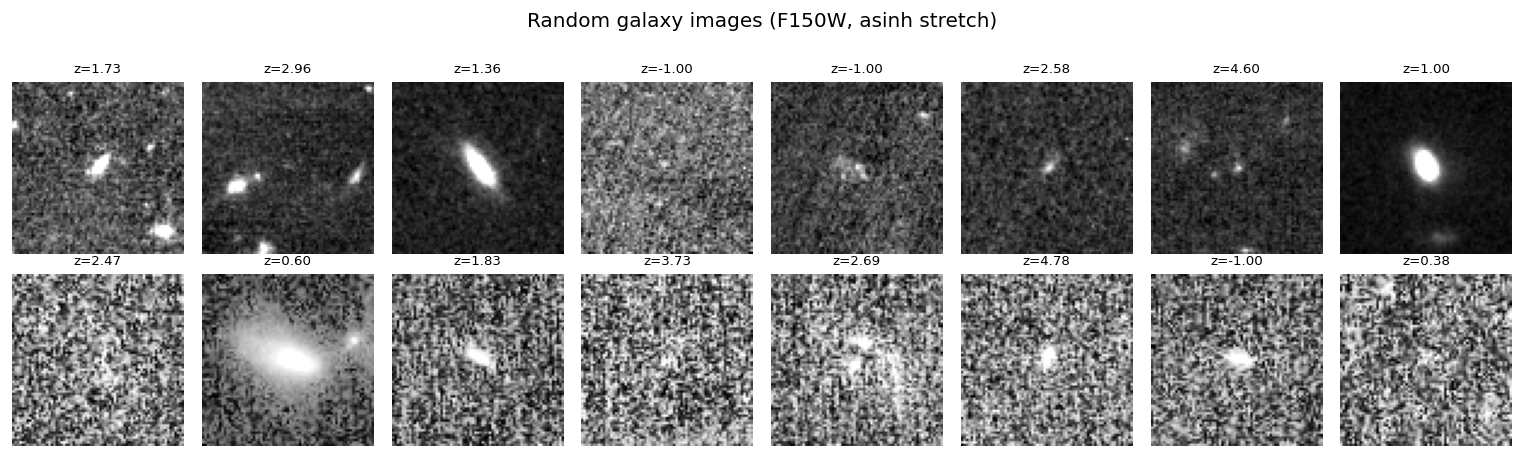

In [21]:
def asinh_stretch(img, a=0.02):
    """Asinh stretch then normalise to [0,1] per image."""
    img = np.arcsinh(img / a)
    lo, hi = np.percentile(img, [0.5, 99.5])
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)

rng = np.random.default_rng(None)
N_SHOW = 8

#plot center 72x72 region of random galaxies, with asinh stretch
fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 1.6, 3.8))
for row, (ds, label) in enumerate([(dja, 'DJA'), (cos, 'COSMOS')]):
    idx = rng.choice(len(ds['image']), N_SHOW, replace=False)
    for col, i in enumerate(idx):
        img = asinh_stretch(ds['image'][i])
        img = img[28:99, 28:99]  # center 72x72 region
        axes[row, col].imshow(img, cmap='gray', origin='lower')
        z = ds['z_best'][i]
        axes[row, col].set_title(f'z={z:.2f}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=11, rotation=0, labelpad=36)

fig.suptitle('Random galaxy images (F150W, asinh stretch)', y=1.01)
plt.tight_layout()
plt.show()

## 3. Spectrum examples

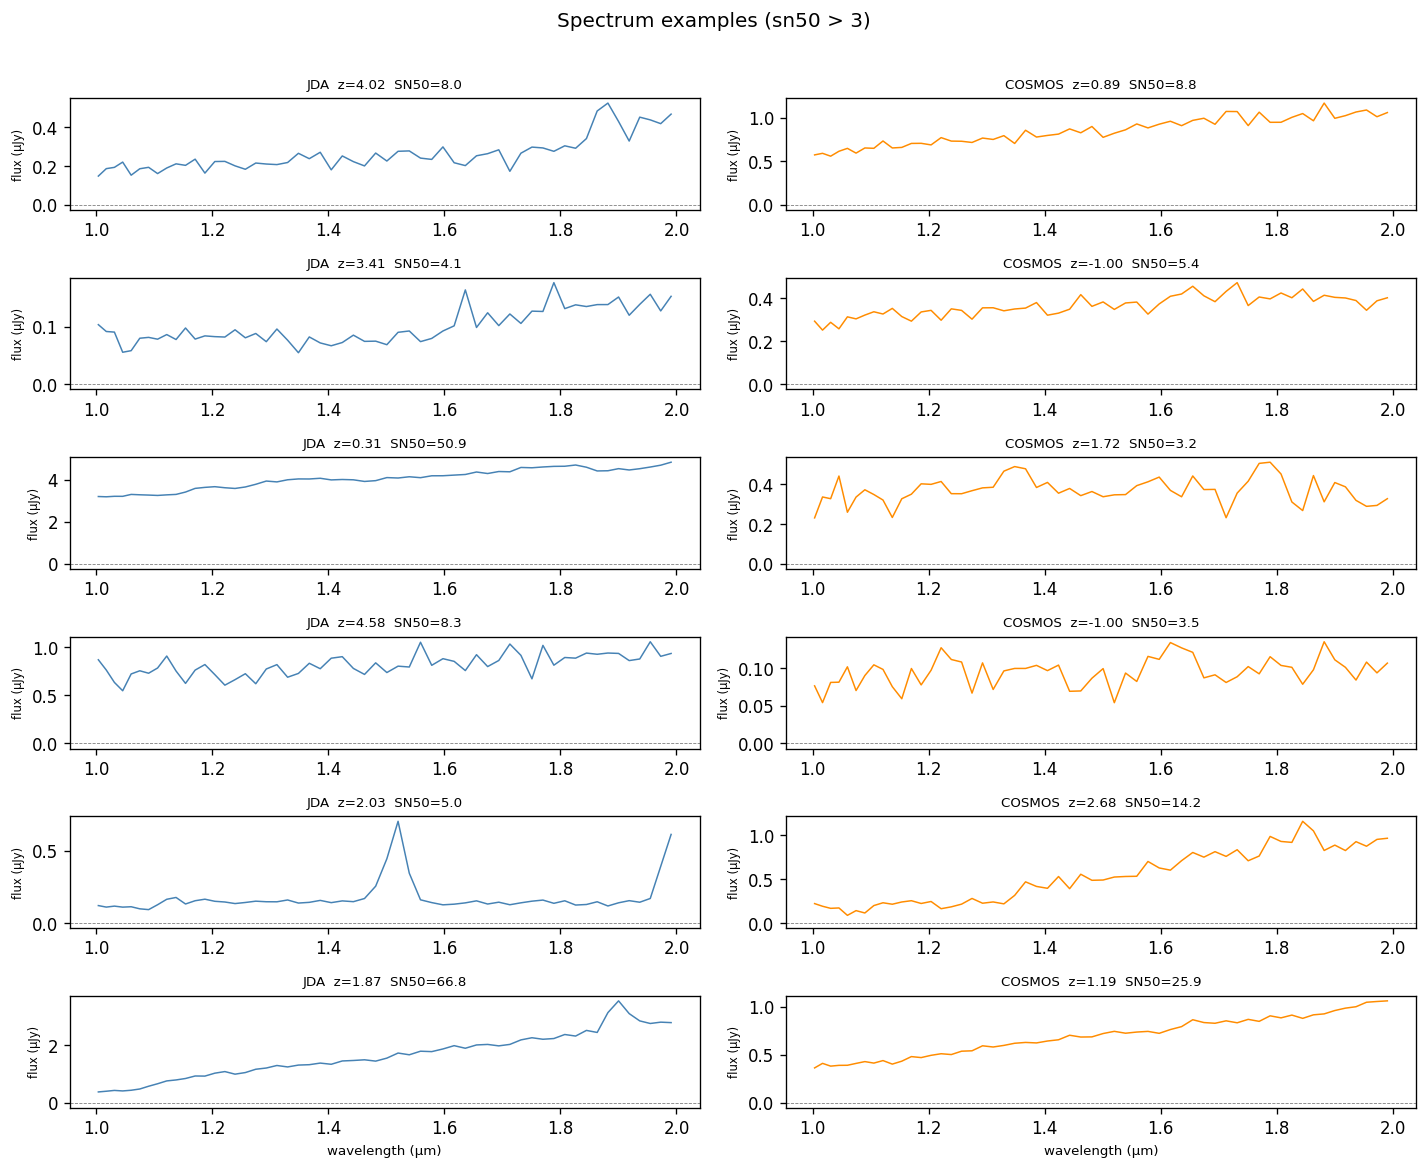

In [4]:
rng2 = np.random.default_rng(1)
N_SPEC = 6

fig, axes = plt.subplots(N_SPEC, 2, figsize=(12, N_SPEC * 1.6), sharex=False)

for col, (ds, label) in enumerate([(dja, 'DJA'), (cos, 'COSMOS')]):
    # pick spectra with reasonable sn50
    good = np.where(ds['sn50'] > 3)[0]
    idx = rng2.choice(good, N_SPEC, replace=False)
    for row, i in enumerate(idx):
        flux = ds['flux'][i]
        wave = ds['wave'][i]
        valid = (flux != 0) & np.isfinite(flux) & np.isfinite(wave)
        ax = axes[row, col]
        ax.plot(wave[valid], flux[valid], lw=0.9, color='steelblue' if col == 0 else 'darkorange')
        ax.axhline(0, lw=0.5, color='gray', ls='--')
        sn = ds['sn50'][i]; z = ds['z_best'][i]
        ax.set_title(f'{label}  z={z:.2f}  SN50={sn:.1f}', fontsize=8)
        ax.set_ylabel('flux (µJy)', fontsize=7)
        if row == N_SPEC - 1:
            ax.set_xlabel('wavelength (µm)', fontsize=8)

plt.suptitle('Spectrum examples (sn50 > 3)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Statistics

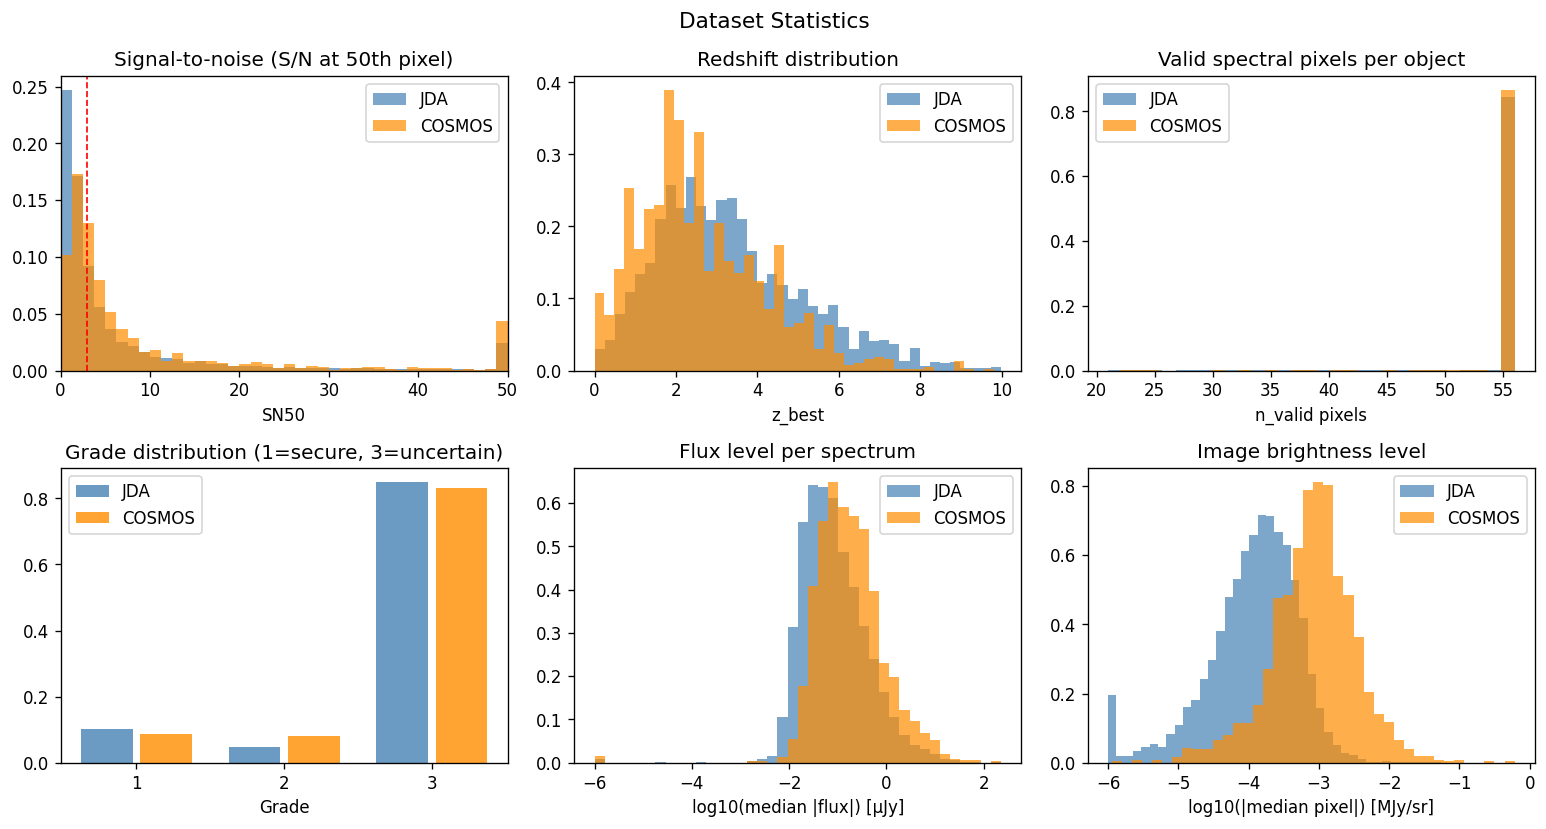

Metric                                JDA          COSMOS
--------------------------------------------------------
N total                            11,924           1,772
z_best (median)                      3.07            2.31
sn50 (median)                        2.35            3.70
n_valid (median)                    56.00           56.00
grade=1 fraction                   10.31%           8.80%
sn50 > 3 fraction                  42.15%          57.96%


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

kw_j = dict(color='steelblue', alpha=0.7, label='DJA', density=True)
kw_c = dict(color='darkorange', alpha=0.7, label='COSMOS', density=True)

# sn50
ax = axes[0, 0]
sn_j = np.clip(dja['sn50'], 0, 50)
sn_c = np.clip(cos['sn50'], 0, 50)
ax.hist(sn_j, bins=40, **kw_j)
ax.hist(sn_c, bins=40, **kw_c)
ax.set_xlabel('SN50'); ax.set_title('Signal-to-noise (S/N at 50th pixel)')
ax.legend(); ax.set_xlim(0, 50)
ax.axvline(3, color='red', lw=1, ls='--', label='sn50=3')

# redshift
ax = axes[0, 1]
z_j = dja['z_best']; z_j = z_j[(z_j >= 0) & (z_j < 10)]
z_c = cos['z_best']; z_c = z_c[(z_c >= 0) & (z_c < 10)]
ax.hist(z_j, bins=40, **kw_j)
ax.hist(z_c, bins=40, **kw_c)
ax.set_xlabel('z_best'); ax.set_title('Redshift distribution')
ax.legend()

# n_valid
ax = axes[0, 2]
ax.hist(dja['n_valid'], bins=30, **kw_j)
ax.hist(cos['n_valid'], bins=30, **kw_c)
ax.set_xlabel('n_valid pixels'); ax.set_title('Valid spectral pixels per object')
ax.legend()

# grade distribution
ax = axes[1, 0]
for ds, label, color in [(dja, 'DJA', 'steelblue'), (cos, 'COSMOS', 'darkorange')]:
    grades, counts = np.unique(ds['grade'], return_counts=True)
    ax.bar(grades + (-0.2 if label == 'DJA' else 0.2), counts / counts.sum(),
           width=0.35, color=color, alpha=0.8, label=label)
ax.set_xlabel('Grade'); ax.set_title('Grade distribution (1=secure, 3=uncertain)')
ax.set_xticks([1, 2, 3]); ax.legend()

# flux range (median absolute flux per spectrum)
ax = axes[1, 1]
med_j = np.nanmedian(np.abs(dja['flux']), axis=1)
med_c = np.nanmedian(np.abs(cos['flux']), axis=1)
ax.hist(np.log10(med_j + 1e-6), bins=40, **kw_j)
ax.hist(np.log10(med_c + 1e-6), bins=40, **kw_c)
ax.set_xlabel('log10(median |flux|) [µJy]'); ax.set_title('Flux level per spectrum')
ax.legend()

# image pixel statistics
ax = axes[1, 2]
med_img_j = np.nanmedian(dja['image'].reshape(len(dja['image']), -1), axis=1)
med_img_c = np.nanmedian(cos['image'].reshape(len(cos['image']), -1), axis=1)
ax.hist(np.log10(np.abs(med_img_j) + 1e-6), bins=40, **kw_j)
ax.hist(np.log10(np.abs(med_img_c) + 1e-6), bins=40, **kw_c)
ax.set_xlabel('log10(|median pixel|) [MJy/sr]'); ax.set_title('Image brightness level')
ax.legend()

plt.suptitle('Dataset Statistics', fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Metric':<25} {'DJA':>15} {'COSMOS':>15}")
print('-' * 56)
print(f"{'N total':<25} {len(dja['image']):>15,} {len(cos['image']):>15,}")
for key, arr_j, arr_c in [
    ('z_best (median)', dja['z_best'][(dja['z_best']>=0)&(dja['z_best']<10)],
                        cos['z_best'][(cos['z_best']>=0)&(cos['z_best']<10)]),
    ('sn50 (median)', dja['sn50'][dja['sn50']>0], cos['sn50'][cos['sn50']>0]),
    ('n_valid (median)', dja['n_valid'].astype(float), cos['n_valid'].astype(float)),
]:
    print(f"{key:<25} {np.median(arr_j):>15.2f} {np.median(arr_c):>15.2f}")
print(f"{'grade=1 fraction':<25} {(dja['grade']==1).mean():>15.2%} {(cos['grade']==1).mean():>15.2%}")
print(f"{'sn50 > 3 fraction':<25} {(dja['sn50']>3).mean():>15.2%} {(cos['sn50']>3).mean():>15.2%}")

## 5. Encoder embedding space (DJA)

PCA and UMAP of image and spectrum embeddings, coloured by redshift / sn50 / grade.

In [6]:
from sklearn.decomposition import PCA

# Use objects with valid redshift and sn50 > 1
mask = (dja['z_best'] >= 0) & (dja['z_best'] < 10) & (dja['sn50'] > 1)
ie = dja['image_embed'][mask]     # (M, 512)
se = dja['spectrum_embed'][mask]  # (M, 128)
z  = dja['z_best'][mask]
sn = dja['sn50'][mask]
gr = dja['grade'][mask]

pca_img  = PCA(n_components=2).fit_transform(ie)
pca_spec = PCA(n_components=2).fit_transform(se)
print(f'Objects used: {mask.sum()}  (sn50>1, 0≤z<10)')

Objects used: 8082  (sn50>1, 0≤z<10)


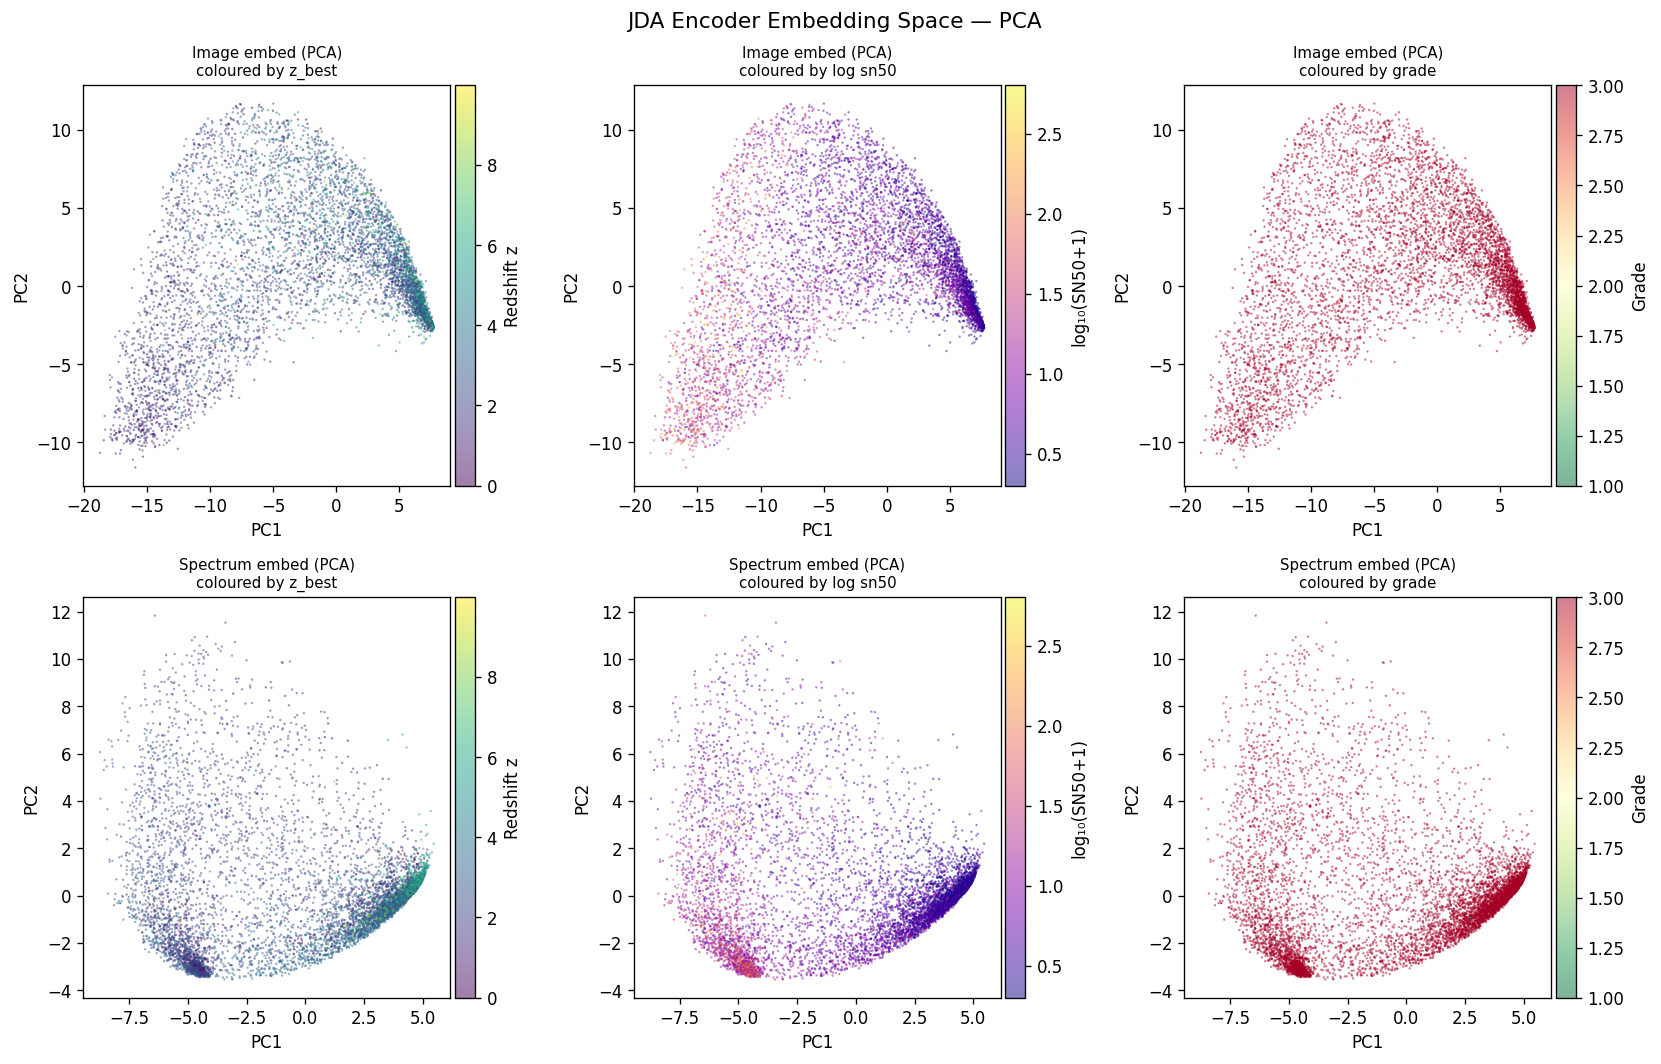

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

colormaps = [('z_best', z, 'viridis', 'Redshift z'),
             ('log sn50', np.log10(sn+1), 'plasma', 'log₁₀(SN50+1)'),
             ('grade', gr, 'RdYlGn_r', 'Grade')]

for col, (cname, cval, cmap, clabel) in enumerate(colormaps):
    for row, (xy, elabel) in enumerate([(pca_img, 'Image embed (PCA)'),
                                         (pca_spec, 'Spectrum embed (PCA)')]):
        ax = axes[row, col]
        sc = ax.scatter(xy[:, 0], xy[:, 1], c=cval, cmap=cmap,
                        s=2, alpha=0.5, linewidths=0, rasterized=True)
        plt.colorbar(sc, ax=ax, label=clabel, pad=0.01)
        ax.set_title(f'{elabel}\ncoloured by {cname}', fontsize=9)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('DJA Encoder Embedding Space — PCA', fontsize=13)
plt.tight_layout()
plt.show()

/home/yacheng/ssl_outthere/.venv/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yacheng/ssl_outthere/.venv/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


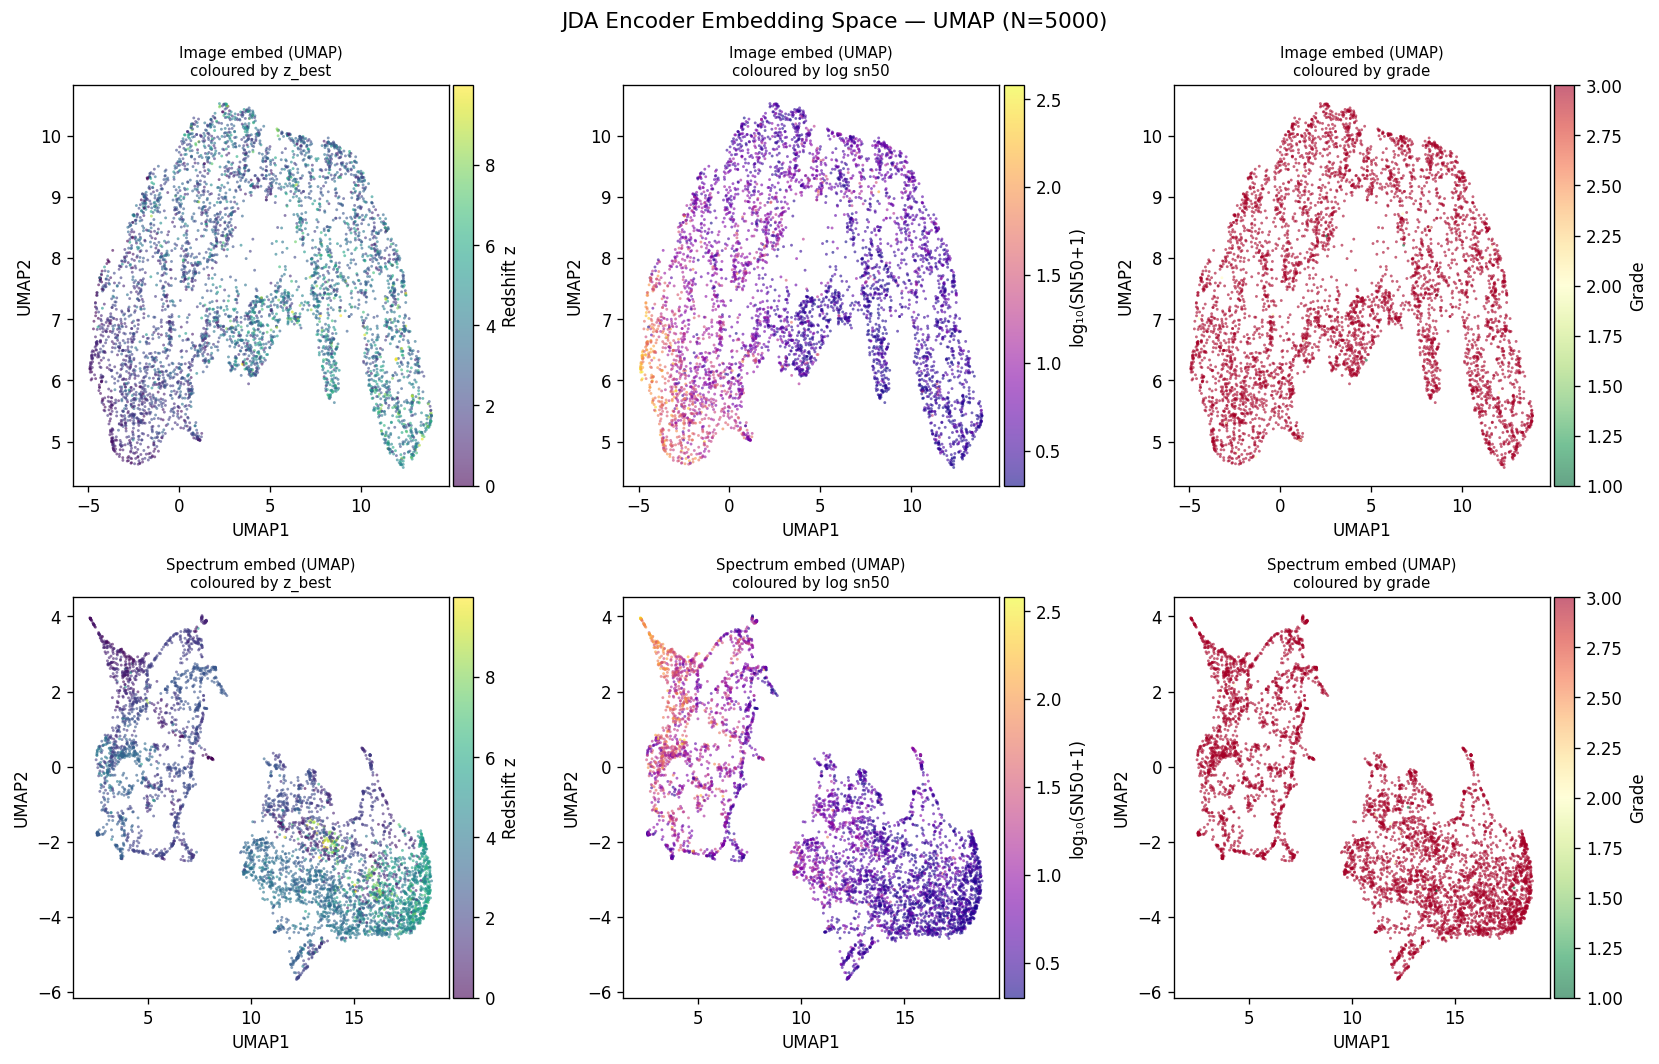

In [8]:
# UMAP (install with: pip install umap-learn)
try:
    import umap
    
    # subsample if large
    N_MAX = 5000
    rng3 = np.random.default_rng(42)
    idx_sub = rng3.choice(len(ie), min(N_MAX, len(ie)), replace=False)
    
    reducer_img  = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
    reducer_spec = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
    
    umap_img  = reducer_img.fit_transform(ie[idx_sub])
    umap_spec = reducer_spec.fit_transform(se[idx_sub])
    z_sub  = z[idx_sub]
    sn_sub = sn[idx_sub]
    gr_sub = gr[idx_sub]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    colormaps_u = [('z_best', z_sub, 'viridis', 'Redshift z'),
                   ('log sn50', np.log10(sn_sub+1), 'plasma', 'log₁₀(SN50+1)'),
                   ('grade', gr_sub, 'RdYlGn_r', 'Grade')]
    
    for col, (cname, cval, cmap, clabel) in enumerate(colormaps_u):
        for row, (xy, elabel) in enumerate([(umap_img, 'Image embed (UMAP)'),
                                             (umap_spec, 'Spectrum embed (UMAP)')]):
            ax = axes[row, col]
            sc = ax.scatter(xy[:, 0], xy[:, 1], c=cval, cmap=cmap,
                            s=3, alpha=0.6, linewidths=0, rasterized=True)
            plt.colorbar(sc, ax=ax, label=clabel, pad=0.01)
            ax.set_title(f'{elabel}\ncoloured by {cname}', fontsize=9)
            ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
    
    plt.suptitle(f'DJA Encoder Embedding Space — UMAP (N={len(idx_sub)})', fontsize=13)
    plt.tight_layout()
    plt.show()

except ImportError:
    print('umap-learn not installed. Run:  pip install umap-learn')

In [ ]:
# Pre-fusion embedding alignment
# image_embed (512-d) and spectrum_embed (128-d) live in different spaces.
# Project image_embed → 128-d with PCA for a rough pre-fusion cosine similarity.
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

ie_128   = PCA(n_components=128, random_state=0).fit_transform(ie)   # 512 → 128
ie_norm  = normalize(ie_128)
se_norm  = normalize(se)          # already 128-d

cos_sim = (ie_norm * se_norm).sum(axis=1)   # (M,) cosine similarity per pair

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
ax.hist(cos_sim, bins=60, color='mediumseagreen', alpha=0.8)
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('cosine similarity  (image PCA-128 ↔ spectrum)')
ax.set_title(f'Pre-fusion alignment\nmedian={np.median(cos_sim):.3f}  (random≈0)')

ax = axes[1]
sc = ax.scatter(z, cos_sim, c=np.log10(sn+1), cmap='plasma', s=2, alpha=0.4, rasterized=True)
plt.colorbar(sc, ax=ax, label='log₁₀(SN50+1)')
ax.set_xlabel('z_best'); ax.set_ylabel('cosine similarity')
ax.set_title('Alignment vs redshift')

ax = axes[2]
sn_bins = np.percentile(sn, np.linspace(0, 100, 20))
bin_idx = np.digitize(sn, sn_bins) - 1
bin_med = [np.median(cos_sim[bin_idx == b]) for b in range(len(sn_bins)-1)]
bin_cent = 0.5 * (sn_bins[:-1] + sn_bins[1:])
ax.plot(bin_cent, bin_med, 'o-', color='steelblue')
ax.axhline(0, color='gray', lw=0.8, ls='--', label='random baseline')
ax.set_xlabel('SN50'); ax.set_ylabel('median cosine similarity')
ax.set_title('Alignment vs S/N')
ax.set_xscale('log'); ax.legend()

plt.suptitle('JDA: Pre-fusion encoder alignment\n(image PCA-128 vs spectrum embed)', fontsize=12)
plt.tight_layout()
plt.show()

print('Cosine similarity (pre-fusion PCA-128 projection):')
for p in [10, 25, 50, 75, 90]:
    print(f'  p{p:2d}: {np.percentile(cos_sim, p):.4f}')
print('Note: values near 0 are expected before fusion training.')